In [1]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [2]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v01_version_para_regresion.csv'
#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas_brutas.csv'

dataset = '/content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_ventas.csv'

In [4]:
#cargamos el dataset y mostramos las primeras filas
try:
    df = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_ventas.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34


In [ ]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(df.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())
print("\nUltimas 5 filas del dataset:")
display(df.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(df.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(df.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(df.describe(include='object'))



Dimensiones del dataset:
Filas: 522010
Columnas: 15

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country',
       'InvoiceDay', 'InvoiceMonth', 'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,1,12,2010,8,2,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,1,12,2010,8,2,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,1,12,2010,8,2,1,20.34



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
522005,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France,9,12,2011,12,4,0,10.20
522006,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France,9,12,2011,12,4,0,12.60
522007,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60
522008,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France,9,12,2011,12,4,0,16.60
522009,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France,9,12,2011,12,4,0,14.85



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522010 entries, 0 to 522009
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     522010 non-null  int64  
 1   StockCode     522010 non-null  object 
 2   Description   522010 non-null  object 
 3   Quantity      522010 non-null  int64  
 4   InvoiceDate   522010 non-null  object 
 5   UnitPrice     522010 non-null  float64
 6   CustomerID    390600 non-null  float64
 7   Country       522010 non-null  object 
 8   InvoiceDay    522010 non-null  int64  
 9   InvoiceMonth  522010 non-null  int64  
 10  InvoiceYear   522010 non-null  int64  
 11  InvoiceHour   522010 non-null  int64  
 12  DayOfWeek     522010 non-null  int64  
 13  IsUk          522010 non-null  int64  
 14  TotalPrice    522010 non-null  float64
dtypes: float64(3), int64(8), object(4)
memory usage: 59.7+ MB


None


Resumen estadístico del dataset:


,InvoiceNo,Quantity,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,"522,010.00","522,010.00","522,010.00","390,600.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00","522,010.00"
mean,"559,962.20",10.32,3.27,"15,295.82",15.02,7.55,"2,010.92",13.08,2.43,0.92,19.09
std,"13,422.16",37.81,4.38,"1,710.32",8.66,3.51,0.27,2.44,1.85,0.28,84.60
min,"536,365.00",1.00,0.00,"12,347.00",1.00,1.00,"2,010.00",6.00,0.00,0.00,0.00
25%,"547,906.00",1.00,1.25,"13,969.00",7.00,5.00,"2,011.00",11.00,1.00,1.00,3.90
50%,"560,690.00",4.00,2.08,"15,159.00",15.00,8.00,"2,011.00",13.00,2.00,1.00,9.90
75%,"571,824.00",12.00,4.13,"16,794.00",22.00,11.00,"2,011.00",15.00,4.00,1.00,17.70
max,"581,587.00","4,800.00",649.50,"18,287.00",31.00,12.00,"2,011.00",20.00,6.00,1.00,"38,970.00"



Resumen descriptivo del dataset:


,StockCode,Description,InvoiceDate,Country
count,522010,522010,522010,522010
unique,3912,4017,18288,38
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-10-31 14:41:00,United Kingdom
freq,2252,2310,1113,478466


In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

522010

# Preprocesado y transformación de datos




In [5]:
print("\n--- 1. PREPARACIÓN DE DATOS DIARIOS Y FEATURE ENGINEERING ---")

# Rangos exactos (igual que Prophet)
start_train = '2010-12-01'
end_train   = '2011-11-08'
start_val   = '2011-10-09'
end_val     = '2011-11-08'
start_test  = '2011-11-09'
end_test    = '2011-12-09'

def preprocess_for_rf(df, target_col='TotalPrice'):
    # Agregación Diaria
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.normalize()
    df_daily = df.groupby('InvoiceDate')[target_col].sum().reset_index()
    df_daily.columns = ['date', 'daily_sales']

    # FEATURE ENGINEERING
    df_daily['month'] = df_daily['date'].dt.month
    df_daily['day_of_month'] = df_daily['date'].dt.day
    df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
    df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)

    # Variables de "Memoria" (Lags)
    df_daily['sales_lag_1'] = df_daily['daily_sales'].shift(1)
    df_daily['sales_lag_7'] = df_daily['daily_sales'].shift(7)

    # Medias móviles y tendencias
    df_daily['rolling_mean_7'] = df_daily['daily_sales'].shift(1).rolling(window=7).mean()
    df_daily['rolling_mean_30'] = df_daily['daily_sales'].shift(1).rolling(window=30).mean()
    df_daily['trend_1_vs_7'] = df_daily['sales_lag_1'] - df_daily['sales_lag_7']

    # Rellenamos los primeros días que no tienen lag con la media
    df_daily.bfill(inplace=True)

    # 4. División de conjuntos
    df_train = df_daily[(df_daily['date'] >= start_train) & (df_daily['date'] <= end_train)].copy()
    df_val   = df_daily[(df_daily['date'] >= start_val)   & (df_daily['date'] <= end_val)].copy()
    df_test  = df_daily[(df_daily['date'] >= start_test)  & (df_daily['date'] <= end_test)].copy()

    print(f" ==== Reporte de Datos: ====== ")
    print(f"   - Entrenamiento: {len(df_train)} días")
    print(f"   - Validación:    {len(df_val)} días")
    print(f"   - Test Final:    {len(df_test)} días")

    return df_train, df_val, df_test

# Ejecutamos el preprocesado
df_train, df_val, df_test = preprocess_for_rf(df, 'TotalPrice')





--- 1. PREPARACIÓN DE DATOS DIARIOS Y FEATURE ENGINEERING ---
 ==== Reporte de Datos: ====== 
   - Entrenamiento: 278 días
   - Validación:    27 días
   - Test Final:    27 días


 Modelos VARIOS




 Procesando: Regresión Multilineal...
 -> Entrenando modelo directo (sin hiperparámetros)...

[ ESCENARIO A ] TEST COMPLETO (Incluyendo 2011-11-14)
   - RMSE: £16,560.37

[ ESCENARIO B ] CORREGIDO (Excluyendo 2011-11-14)
   - RMSE: £12,631.64 (Mejora: £3,928.74)
 -> ✅ Dataset de ventas guardado en: /content/drive/MyDrive/TFM_Prediccion_Ventas_Regresion_Multilineal.csv


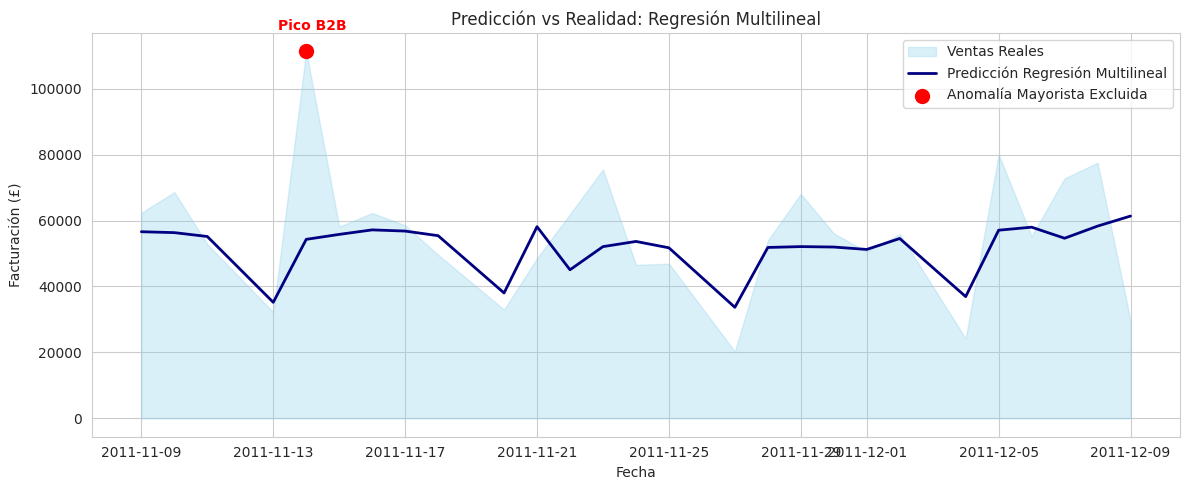


 Procesando: Regresión Polinómica (Grado 2)...
 -> Entrenando modelo directo (sin hiperparámetros)...

[ ESCENARIO A ] TEST COMPLETO (Incluyendo 2011-11-14)
   - RMSE: £22,258.52

[ ESCENARIO B ] CORREGIDO (Excluyendo 2011-11-14)
   - RMSE: £19,530.43 (Mejora: £2,728.08)
 -> ✅ Dataset de ventas guardado en: /content/drive/MyDrive/TFM_Prediccion_Ventas_Regresion_Polinomica_(Grado_2).csv


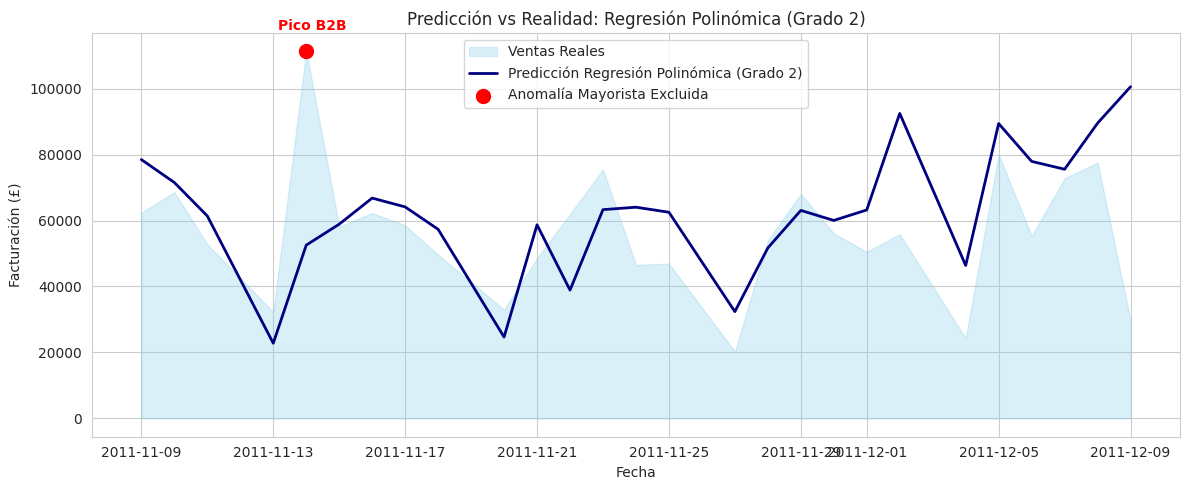


 Procesando: Árbol de Decisión...
 -> Optimizando hiperparámetros con RandomizedSearchCV...
 -> Mejores parámetros: {'min_samples_split': 15, 'max_depth': 15}

[ ESCENARIO A ] TEST COMPLETO (Incluyendo 2011-11-14)
   - RMSE: £19,785.80

[ ESCENARIO B ] CORREGIDO (Excluyendo 2011-11-14)
   - RMSE: £13,590.11 (Mejora: £6,195.69)
 -> ✅ Dataset de ventas guardado en: /content/drive/MyDrive/TFM_Prediccion_Ventas_Arbol_de_Decision.csv


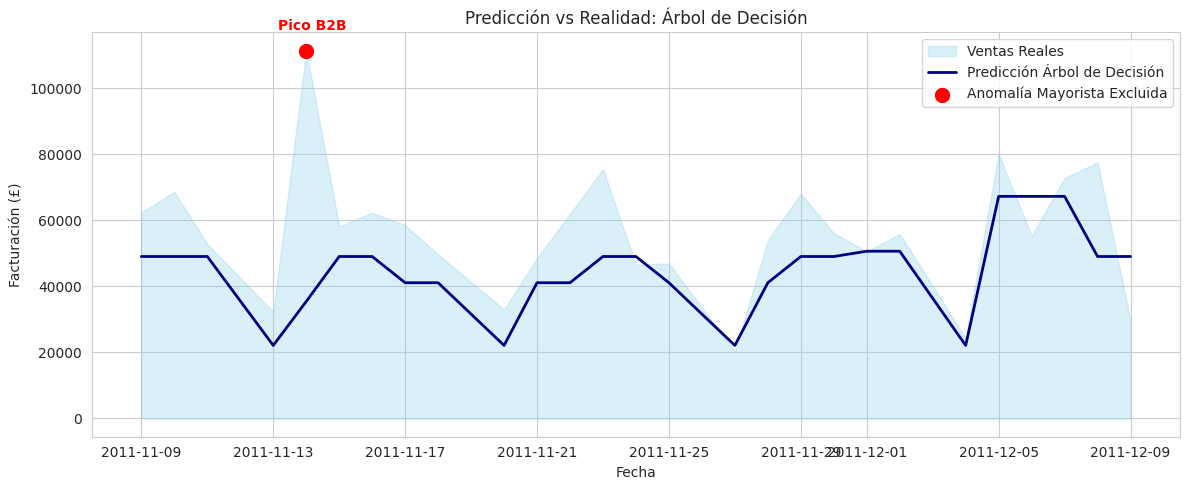


 Procesando: XGBoost...
 -> Optimizando hiperparámetros con RandomizedSearchCV...
 -> Mejores parámetros: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}

[ ESCENARIO A ] TEST COMPLETO (Incluyendo 2011-11-14)
   - RMSE: £20,904.64

[ ESCENARIO B ] CORREGIDO (Excluyendo 2011-11-14)
   - RMSE: £16,380.91 (Mejora: £4,523.73)
 -> ✅ Dataset de ventas guardado en: /content/drive/MyDrive/TFM_Prediccion_Ventas_XGBoost.csv


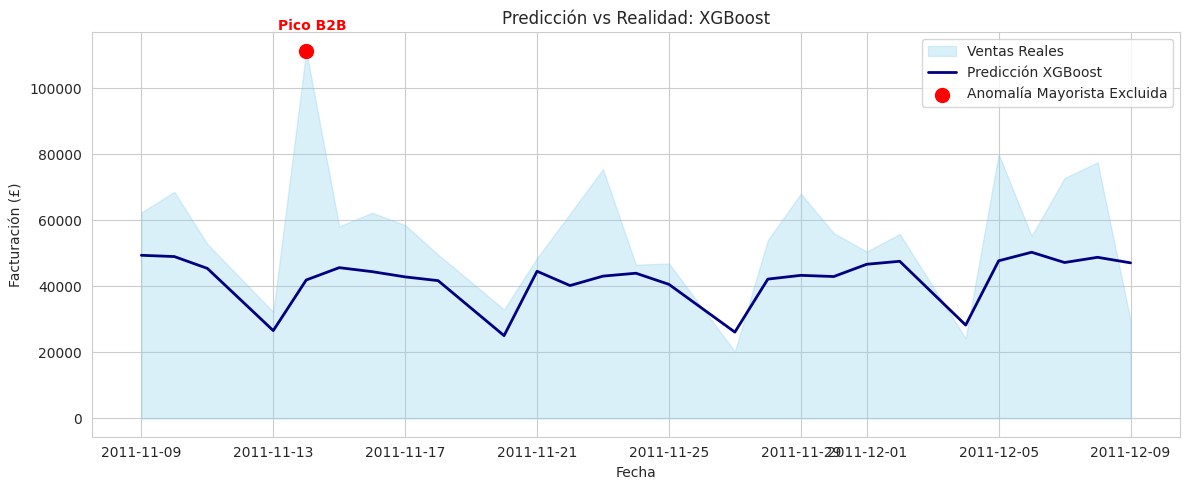


 TABLA DE RESULTADOS: ESCENARIO A (TEST COMPLETO CON ANOMALÍA)


,Modelo,MAE (£),RMSE (£),R2
0,Regresión Multilineal,"11,381.53","16,560.37",0.23
2,Árbol de Decisión,"13,761.00","19,785.80",-0.10
3,XGBoost,"15,721.83","20,904.64",-0.23
1,Regresión Polinómica (Grado 2),"15,328.05","22,258.52",-0.40



 TABLA DE RESULTADOS: ESCENARIO B (CORREGIDO - EXCLUYENDO ANOMALÍA)


,Modelo,MAE (£),RMSE (£),R2
0,Regresión Multilineal,"9,624.57","12,631.64",0.35
2,Árbol de Decisión,"11,369.23","13,590.11",0.25
3,XGBoost,"13,655.61","16,380.91",-0.09
1,Regresión Polinómica (Grado 2),"13,655.36","19,530.43",-0.55


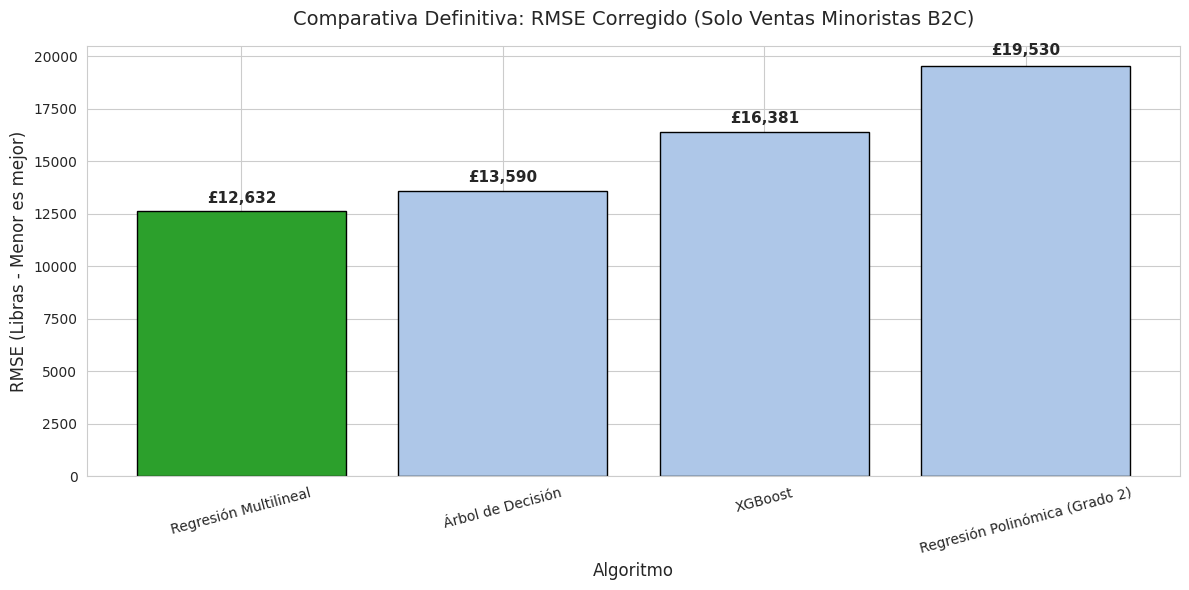

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

features = [
    'month', 'day_of_month', 'day_of_week', 'is_weekend',
    'sales_lag_1', 'sales_lag_7',
    'rolling_mean_7', 'rolling_mean_30', 'trend_1_vs_7'
]
target = 'daily_sales'

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]


# CONFIGURACIÓN DE MODELOS Y VALIDACIÓN CRUZADA

tscv = TimeSeriesSplit(n_splits=3)

#Declaro los distintos modelos
modelos = {
    "Regresión Multilineal": LinearRegression(),
    "Regresión Polinómica (Grado 2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror')
}

#Parametros para arbol de decisión
param_grids = {

    "Árbol de Decisión": {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [5, 10, 15]
    },
    # Parametros optimizados para XGBoost:
    "XGBoost": {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'gamma': [0, 0.1, 0.5]
    }
}


# ENTRENAMIENTO, OPTIMIZACIÓN Y EVALUACIÓN MULTI-MODELO

resultados_completos = []
resultados_corregidos = []
predicciones_test = {}

# Fecha de la anomalía B2B que queremos aislar
fecha_anomala = '2011-11-14'

for nombre, modelo in modelos.items():
    print("\n" + "="*80)
    print(f" Procesando: {nombre}...")
    print("="*80)

    if nombre in param_grids:
        print(f" -> Optimizando hiperparámetros con RandomizedSearchCV...")


        # Si es XGBoost usamos 40, si es el Árbol usamos 10
        iteraciones = 40 if nombre == "XGBoost" else 10

        random_search = RandomizedSearchCV(
            estimator=modelo,
            param_distributions=param_grids[nombre],
            n_iter=iteraciones,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            random_state=42,
            n_jobs=-1
        )
        random_search.fit(X_train, y_train)
        mejor_modelo = random_search.best_estimator_
        print(f" -> Mejores parámetros: {random_search.best_params_}")

    else:
        # Si es regresión simple/polinómica, entrenamos directo
        print(" -> Entrenando modelo directo (sin hiperparámetros)...")
        mejor_modelo = modelo.fit(X_train, y_train)

    # PREDICCIÓN BASE
    y_pred = mejor_modelo.predict(X_test)
    predicciones_test[nombre] = y_pred

    # Preparamos DataFrame de evaluación para este modelo
    df_eval_mod = df_test.copy()
    df_eval_mod['actual_sales'] = df_eval_mod[target]
    df_eval_mod['predicted_sales'] = y_pred


    # ESCENARIO A: TEST COMPLETO

    mae_full = mean_absolute_error(df_eval_mod['actual_sales'], df_eval_mod['predicted_sales'])
    rmse_full = np.sqrt(mean_squared_error(df_eval_mod['actual_sales'], df_eval_mod['predicted_sales']))
    r2_full = r2_score(df_eval_mod['actual_sales'], df_eval_mod['predicted_sales'])

    resultados_completos.append({
        "Modelo": nombre,
        "MAE (£)": mae_full,
        "RMSE (£)": rmse_full,
        "R2": r2_full
    })

    print(f"\n[ ESCENARIO A ] TEST COMPLETO (Incluyendo {fecha_anomala})")
    print(f"   - RMSE: £{rmse_full:,.2f}")


    # ESCENARIO B: CORREGIDO

    df_eval_corr = df_eval_mod[df_eval_mod['date'].astype(str) != fecha_anomala]

    mae_corr = mean_absolute_error(df_eval_corr['actual_sales'], df_eval_corr['predicted_sales'])
    rmse_corr = np.sqrt(mean_squared_error(df_eval_corr['actual_sales'], df_eval_corr['predicted_sales']))
    r2_corr = r2_score(df_eval_corr['actual_sales'], df_eval_corr['predicted_sales'])

    resultados_corregidos.append({
        "Modelo": nombre,
        "MAE (£)": mae_corr,
        "RMSE (£)": rmse_corr,
        "R2": r2_corr
    })

    print(f"\n[ ESCENARIO B ] CORREGIDO (Excluyendo {fecha_anomala})")
    print(f"   - RMSE: £{rmse_corr:,.2f} (Mejora: £{rmse_full - rmse_corr:,.2f})")

    nombre_archivo = nombre.replace(" ", "_").replace("ó", "o").replace("í", "i").replace("Á", "A")
    ruta_drive = f'/content/drive/MyDrive/TFM_Prediccion_Ventas_{nombre_archivo}.csv'

    # Guardamos el DataFrame ya corregido (df_eval_corr)
    df_eval_corr.to_csv(ruta_drive, index=False)
    print(f" -> ✅ Dataset de ventas guardado en: {ruta_drive}")

    # GRÁFICA INDIVIDUAL POR MODELO

    plt.figure(figsize=(12, 5))

    plt.fill_between(df_eval_mod['date'], df_eval_mod['actual_sales'], color="skyblue", alpha=0.3, label='Ventas Reales')
    plt.plot(df_eval_mod['date'], df_eval_mod['predicted_sales'], color="navy", lw=2, label=f'Predicción {nombre}')

    # Resaltar la anomalía
    venta_anomala = df_eval_mod[df_eval_mod['date'].astype(str) == fecha_anomala]
    if not venta_anomala.empty:
        plt.scatter(venta_anomala['date'], venta_anomala['actual_sales'],
                    color='red', s=100, zorder=5, label='Anomalía Mayorista Excluida')
        plt.annotate('Pico B2B',
                     xy=(venta_anomala['date'].iloc[0], venta_anomala['actual_sales'].iloc[0]),
                     xytext=(-20, 15), textcoords='offset points',
                     color='red', fontweight='bold')

    plt.title(f"Predicción vs Realidad: {nombre}", fontsize=12)
    plt.xlabel("Fecha", fontsize=10)
    plt.ylabel("Facturación (£)", fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()


# TABLAS COMPARATIVAS FINALES

# Convertimos resultados a DataFrames
df_res_completos = pd.DataFrame(resultados_completos).sort_values(by="RMSE (£)", ascending=True)
df_res_corregidos = pd.DataFrame(resultados_corregidos).sort_values(by="RMSE (£)", ascending=True)

print("\n" + "="*80)
print(" TABLA DE RESULTADOS: ESCENARIO A (TEST COMPLETO CON ANOMALÍA)")
print("="*80)
display(df_res_completos.round(2))

print("\n" + "="*80)
print(" TABLA DE RESULTADOS: ESCENARIO B (CORREGIDO - EXCLUYENDO ANOMALÍA)")
print("="*80)
display(df_res_corregidos.round(2))

# GRÁFICO COMPARATIVO FINAL (USANDO RMSE CORREGIDO)
plt.figure(figsize=(12, 6))

# Destacamos al ganador (índice 0 tras ordenar) en verde, el resto en azul claro
colores = ['#2ca02c' if i == 0 else '#aec7e8' for i in range(len(df_res_corregidos))]
barras = plt.bar(df_res_corregidos['Modelo'], df_res_corregidos['RMSE (£)'], color=colores, edgecolor='black')

plt.title("Comparativa Definitiva: RMSE Corregido (Solo Ventas Minoristas B2C)", fontsize=14, pad=15)
plt.ylabel("RMSE (Libras - Menor es mejor)", fontsize=12)
plt.xlabel("Algoritmo", fontsize=12)
plt.xticks(rotation=15)


for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + (yval*0.02), f'£{yval:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()